# Lecture 03 Practice - Build a kNN Classifier

This practice notebook focuses on building and using a small classifier. The support file `classifiers.py` contains complete reference implementations used in the theory notebook. Here, the missing parts are implemented step by step.

Answers are encoded next to the exercises. Running an answer cell reveals the solution and explanation.


In [1]:
import base64
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)
ANSWER_KEY = 73

def reveal_answer(encoded):
    raw = base64.b64decode(encoded)
    text = bytes(byte ^ ANSWER_KEY for byte in raw).decode("utf-8")
    from IPython.display import Markdown, display
    display(Markdown(text))

def plot_2d_dataset(X, y, query=None, title=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    for label in sorted(set(y)):
        mask = np.asarray(y) == label
        ax.scatter(X[mask, 0], X[mask, 1], s=80, label=f"class {label}")
    if query is not None:
        ax.scatter([query[0]], [query[1]], marker="*", s=300, color="black", label="query")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    if title:
        ax.set_title(title)
    ax.legend()
    plt.show()


## Exercise 1 - Objects to Feature Vectors

Create a NumPy matrix `X` with four observations and two features: height and weight. Create a label array `y` with binary labels. Then print the shape of `X` and explain what the rows and columns mean.


In [ ]:
# TODO: create X and y.
# Example feature order: [height, weight]
#Example of observations and features
height = [1,2,3,4]
weight = [5,6,7,8]

#Defune the matrix with X and y
X = np.array([height,weight]).T
y = np.array([0,1,0,1])

print(X.shape)
print(y.shape)




(4, 2)
(4,)


## Exercise 2 - Implement Distance Strategies

Complete `L1Distance` and `SquaredL2Distance`.


In [25]:
from math import sqrt

class L1Distance:
    def distance(self, a, b):
        a = np.array(a)
        b = np.array(b)

        return np.sum(np.abs(a-b))

class SquaredL2Distance:
    def distance(self, a, b):
        a = np.array(a)
        b = np.array(b)
        return np.sum((a-b)**2)



print(L1Distance().distance(np.array([0, 0]), np.array([3, 4])))
print(SquaredL2Distance().distance(np.array([0, 0]), np.array([3, 4])))


7
25


## Exercise 3 - Implement Majority Voting

Complete `majority_vote(labels)`. In a tie, choose the smallest label after sorting.


In [27]:

def majority_vote(labels):
    labels = sorted(labels)
    best_label = None
    best_count = 0
    for label in labels:
        count = labels.count(label)
        if count > best_count:
            best_count = count
            best_label = label
    return best_label
        
    
 
print(majority_vote(["A", "B", "A", "C", "B", "A"]))


A


## Exercise 4 - Implement Probability Voting

Complete `vote_probabilities(labels, classes)`. The result should be a dictionary where probabilities sum to `1`.


In [29]:
def vote_probabilities(labels, classes):
    counts = Counter(labels)
    total = len(labels)
    probabilities = {}
    for c in classes: 
        probabilities[c]= counts[c]/total
    return probabilities    

print(vote_probabilities([3, 3, 3, 3, 8, 8, 8], classes=[3, 8]))


{3: 0.5714285714285714, 8: 0.42857142857142855}


## Exercise 5 - Finish `predict_one`

Complete `predict_one`: compute all distances, select the `k` smallest, collect their labels, and return the majority label.


In [ ]:
class MyKNNClassifier:
    def __init__(self, k=3, distance=None):
        self.k = k
        self.distance = distance or SquaredL2Distance()

    def fit(self, X, y):
        self.X_train = [np.asarray(row) for row in X]
        self.y_train = list(y)
        return self

    def predict_one(self, x):
        distances = [self.distance.distance(x, train_x) for train_x in self.X_train]
        order = sorted(range(len(distances)), key=lambda i: distances[i])[:self.k]
        neighbor_labels = [self.y_train[i] for i in order]
        return majority_vote(neighbor_labels)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])


### Encoded answer - Exercise 5


In [30]:
reveal_answer('amppDDEsOyogOixpfENDCGktIDssKj1pICQ5JSwkLCc9KD0gJidpKignaTomOz1pKCUlaT07KCAnICcuaSAnLSAqLDppKzBpLSA6PSgnKixnQ0MpKSk5MD0hJidDLSwvaTk7LC0gKj0WJicsYTosJS9laTFgc0NpaWlpLSA6PSgnKiw6aXRpEjosJS9nLSA6PSgnKixnLSA6PSgnKixhMWVpPTsoICcWMWBpLyY7aT07KCAnFjFpICdpOiwlL2cRFj07KCAnFENpaWlpJjstLDtpdGk6Jjs9LC1hOygnLixhJSwnYS0gOj0oJyosOmBgZWkiLDB0JSgkKy0oaSBzaS0gOj0oJyosOhIgFGASczosJS9nIhRDaWlpaScsIC4hKyY7FiUoKywlOml0aRI6LCUvZzAWPTsoICcSIBRpLyY7aSBpICdpJjstLDsUQ2lpaWk7LD08OydpJCgjJjsgPTAWPyY9LGEnLCAuISsmOxYlKCssJTpgQykpKQ==')


## Exercise 5

A direct implementation can sort all training indices by distance.

```python
def predict_one(self, x):
    distances = [self.distance.distance(x, train_x) for train_x in self.X_train]
    order = sorted(range(len(distances)), key=lambda i: distances[i])[:self.k]
    neighbor_labels = [self.y_train[i] for i in order]
    return majority_vote(neighbor_labels)
```

## Exercise 6 - Use the Classifier on a Toy Dataset

Train `MyKNNClassifier` on the toy data below. Predict the class of the query point for `k=1`, `k=3`, and `k=5`.


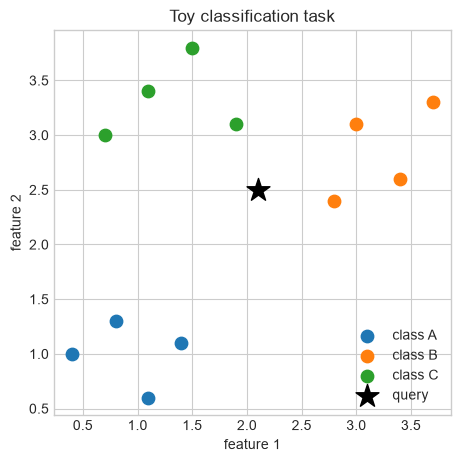

K= 1 prediction =  None
K= 3 prediction =  None
K= 5 prediction =  None


In [31]:
X_toy = np.array([
    [0.4, 1.0], [0.8, 1.3], [1.1, 0.6], [1.4, 1.1],
    [3.0, 3.1], [3.4, 2.6], [3.7, 3.3], [2.8, 2.4],
    [1.1, 3.4], [1.5, 3.8], [0.7, 3.0], [1.9, 3.1],
])
y_toy = np.array(["A", "A", "A", "A", "B", "B", "B", "B", "C", "C", "C", "C"])
query = np.array([2.1, 2.5])
plot_2d_dataset(X_toy, y_toy, query=query, title="Toy classification task")

# TODO: train and predict for k=1, 3, 5.
k = [1,3,5]
for i in k:
    model = MyKNNClassifier(k=1)
    model.fit(X_toy,y_toy)
    prediction = model.predict_one(query)
    print("K=",i,"prediction = ",prediction)
    


## Exercise 7 - Distance-Weighted Voting

Implement inverse-distance weighted voting. Use `weight_i = 1/(distance_i + epsilon)`. Return both the predicted class and normalized probabilities.


In [14]:
def distance_weighted_vote(labels, distances, classes, epsilon=1e-8):
    # TODO
    pass

labels = ["A", "A", "B", "B", "B"]
distances = [0.10, 0.12, 1.10, 1.20, 1.30]
print(distance_weighted_vote(labels, distances, classes=["A", "B"]))


None


### Encoded answer - Exercise 7


In [15]:
reveal_answer('amppDDEsOyogOixpfkNDHSEsaSolJjosaSkIKWk5JiAnPTppKignaSY8PT4sIC4haT0hLGkkJjssaSc8JCw7Jjw6aSs8PWkvKDs9ISw7aSkLKWk5JiAnPTpnQ0MpKSk5MD0hJidDLSwvaS0gOj0oJyosFj4sIC4hPSwtFj8mPSxhJSgrLCU6ZWktIDo9KCcqLDplaSolKDo6LDplaSw5OiAlJid0eCxkcWBzQ2lpaWk6KiY7LDppdGkyKiU6c2l5Z3lpLyY7aSolOmkgJ2kqJSg6Oiw6NENpaWlpLyY7aSUoKywlZWktIDo9KCcqLGkgJ2kzIDlhJSgrLCU6ZWktIDo9KCcqLDpgc0NpaWlpaWlpaToqJjssOhIlKCssJRRpYnRpeGd5aWZpYS0gOj0oJyosaWJpLDk6ICUmJ2BDaWlpaT0mPSglaXRpOjwkYToqJjssOmc/KCU8LDphYGBDaWlpaTk7JisoKyAlID0gLDppdGkyKiU6c2k6KiY7LGlmaT0mPSglaS8mO2kqJTplaToqJjssaSAnaToqJjssOmcgPSwkOmFgNENpaWlpOTssLSAqPSAmJ2l0aSQgJ2E5OyYrKCsgJSA9ICw6ZWkiLDB0JSgkKy0oaSolOnNpYWQ5OyYrKCsgJSA9ICw6EiolOhRlaSolOmBgQ2lpaWk7LD08OydpOTssLSAqPSAmJ2VpOTsmKygrICUgPSAsOkMpKSk=')


## Exercise 7

The close `A` points can outweigh the more numerous but farther `B` points.

```python
def distance_weighted_vote(labels, distances, classes, epsilon=1e-8):
    scores = {cls: 0.0 for cls in classes}
    for label, distance in zip(labels, distances):
        scores[label] += 1.0 / (distance + epsilon)
    total = sum(scores.values())
    probabilities = {cls: score / total for cls, score in scores.items()}
    prediction = min(probabilities, key=lambda cls: (-probabilities[cls], cls))
    return prediction, probabilities
```

## Exercise 8 - NumPy Distances

For one query point and a training matrix `X_train`, compute all squared L2 distances using NumPy. Then find the 3 nearest indices with `np.argpartition`.


In [16]:
X_train_small = X_toy
query_small = query

# TODO: compute squared L2 distances and the 3 nearest indices.


### Encoded answer - Exercise 8


In [17]:
reveal_answer('amppDDEsOyogOixpcUNDCGk/LCo9JjsgMywtaTomJTw9ICYnaSA6c0NDKSkpOTA9ISYnQy0gLy9pdGkRFj07KCAnFjokKCUlaWRpODwsOzAWOiQoJSVDLSA6PXtpdGknOWc6PCRhLSAvL2ljY2l7ZWkoMSA6dHhgQycsKDssOj1pdGknOWcoOy45KDs9ID0gJidhLSA6PXtlaXtgEnN6FEMnLCg7LDo9aXRpJywoOyw6PRInOWcoOy46Jjs9YS0gOj17EicsKDssOj0UYBRDOTsgJz1hLSA6PXtgQzk7ICc9YScsKDssOj1gQykpKQ==')


## Exercise 8

A vectorized solution is:

```python
diff = X_train_small - query_small
dist2 = np.sum(diff ** 2, axis=1)
nearest = np.argpartition(dist2, 2)[:3]
nearest = nearest[np.argsort(dist2[nearest])]
print(dist2)
print(nearest)
```

## Exercise 9 - MNIST Pipeline Questions

Answer briefly.

1. Why does a 28 by 28 image become 784 features?
2. Why is `x / 255.0` enough for MNIST pixel normalization?
3. Why should general scaler statistics be learned only from the training set?
4. Why are kNN probability estimates not logits?


### Encoded answer - Exercise 9


In [18]:
reveal_answer('amppDDEsOyogOixpcENDeGdpDyUoPT0sJyAnLmk5JSgqLDppKCUlaTkgMSwlOmkgJ2kmJyxpPywqPSY7ZWkoJy1pKXtxaWNpe3FpdGl+cX0pZ2l7Z2kEBwAaHWk5IDEsJWk/KCU8LDppISg/LGkoaSInJj4naS8gMSwtaTsoJy4saS87JiRpKXkpaT0maSl7fHwpZ2l6Z2kdLDo9aS0oPShpJDw6PWk6ICQ8JSg9LGk8JzosLCdpLzw9PDssaS0oPShyaTw6ICcuaSA9aT0maSw6PSAkKD0saTk7LDk7JiosOjogJy5pOj0oPSA6PSAqOmklLCgiOmkgJy8mOyQoPSAmJ2dpfWdpIgcHaTk7JisoKyAlID0gLDppKDssaT8mPSxpLzsoKj0gJic6aSY7aScmOyQoJSAzLC1pPyY9LGk+LCAuIT06Z2kFJi4gPTppKDssaTsoPmkkJi0sJWk6KiY7LDppKywvJjssaTomLz0kKDFn')


## Exercise 9

1. Flattening places all pixels in one vector, and `28 * 28 = 784`. 2. MNIST pixel values have a known fixed range from `0` to `255`. 3. Test data must simulate unseen future data; using it to estimate preprocessing statistics leaks information. 4. kNN probabilities are vote fractions or normalized vote weights. Logits are raw model scores before softmax.

## Optional Challenges

- Implement inverse squared distance weighting.
- Compare L1 and squared L2 on the toy dataset.
- Find a toy query whose prediction changes when `k` changes.
- Load MNIST or the sklearn digits fallback and classify a few images using `MyKNNClassifier` on a very small subset.
- Measure prediction time as training size increases.
